### 1. MNIST 데이터셋 가져오기


In [94]:
# MNIST데이터셋 가져오기
from keras.datasets import mnist

(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

### 2. 탐색적 데이터 분석(EDA)

In [95]:
# data의 shape, led

train_images.shape, train_labels.shape, test_images.shape, test_labels.shape

((60000, 28, 28), (60000,), (10000, 28, 28), (10000,))

In [96]:
len(train_images), len(test_images)

(60000, 10000)

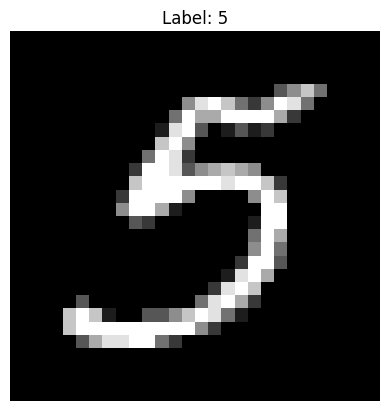

In [97]:
import matplotlib.pyplot as plt
import numpy as np

# train_images에서 랜덤하게 이미지를 선택해서 matplotlib.pyplot으로 시각화
index = np.random.randint(0, train_images.shape[0])
plt.imshow(train_images[index], cmap='gray')
plt.title(f"Label: {train_labels[index]}")
plt.axis('off')
plt.show()

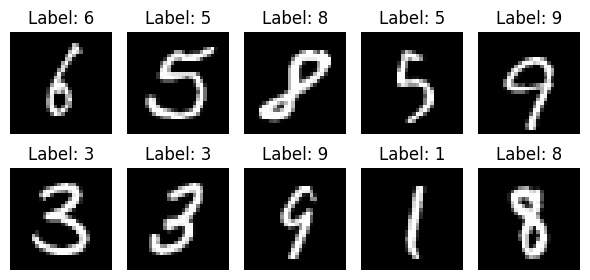

In [98]:
import matplotlib.pyplot as plt
import numpy as np

# 랜덤하게 한번에 10장의 이미지를 출력하기. 2행 5열로 이미지 출력하기

fig, axes = plt.subplots(2, 5, figsize=(6, 3))
axes = axes.flatten() # 2x5 배열을 1차원 배열로 평탄화

for i in range(10):
    index = np.random.randint(0, train_images.shape[0])
    axes[i].imshow(train_images[index], cmap='gray')
    axes[i].set_title(f"Label: {train_labels[index]}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

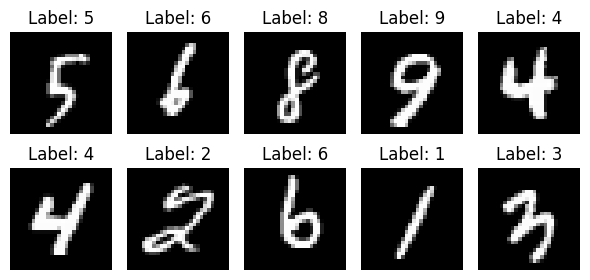

In [99]:
# 테스트 데이터도 확인해보기

import matplotlib.pyplot as plt
import numpy as np

# 랜덤하게 한번에 10장의 이미지를 출력하기. 2행 5열로 이미지 출력하기

fig, axes = plt.subplots(2, 5, figsize=(6, 3))
axes = axes.flatten() # 2x5 배열을 1차원 배열로 평탄화

for i in range(10):
    index = np.random.randint(0, test_images.shape[0])
    axes[i].imshow(train_images[index], cmap='gray')
    axes[i].set_title(f"Label: {train_labels[index]}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()


### 3. 데이터 전처리(valid 데이터 분할까지 포함)

#### 3.1 정규화(Nomalize) : 0 ~ 255(int) -> 0 ~ 1(float)

#### 3.2 레이블을 10진수 -> one-hot encoding

#### 3.3 reshape (60000, 28*28) -> (60000, 784)

In [100]:
# train_images, test_images를 0~1사이의 실수값으로 변경
train_images = train_images.astype('float32') / 255
test_images = test_images.astype('float32') / 255

In [101]:
train_images[0]

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.    

In [102]:
print(train_labels[0:5])
print(test_labels[0:5])
# int
# [5 0 4 1 9]
# [7 2 1 0 4]

[5 0 4 1 9]
[7 2 1 0 4]


In [103]:
# train_labels , test_labels를 one-hot encoding으로 변환
from keras.utils import to_categorical

train_labels = to_categorical(train_labels)
test_labels = to_categorical(test_labels)

In [104]:
print(train_labels[0:5])
print(test_labels[0:5])

[[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]]
[[0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]]


정규화 없이 성능 테스트해보고 나중에 추가

In [105]:
# train_images, test_images를 reshape (60000, 28*28 ) -> 60000, 784)

train_images = train_images.reshape((60000, 28*28))
test_images = test_images.reshape((10000, 28*28))

In [106]:
# train_images, train_labels에서 데이터를 분할
# train:valid=8:2 (48000:12000)
from sklearn.model_selection import train_test_split

train_images, valid_images, train_labels, valid_labels = train_test_split(train_images, train_labels, test_size=0.2, random_state=42)

In [107]:
train_images.shape, train_labels.shape, valid_images.shape, valid_labels.shape

((48000, 784), (48000, 10), (12000, 784), (12000, 10))

### 4. 신경망 모델링

In [115]:
from keras import models
from keras.layers import Dense, Flatten, Input

# keras로 mnist 데이터셋 모델링하기

# 신경망을 쌓아 올리는 방식
model = models.Sequential()

# 입력층(Input)을 정의
model.add(Input(shape=(28*28,)))
# 윗줄과 동일한 코드
# model.add(Input(shape=(28,28)))
# model.add(Flatten()) # 모든 차원을 -> 1차원으로 변경

# 은닉층(Hidden)을 정의
model.add(Dense(512, activation='relu'))
model.add(Dense(256, activation='relu'))
model.add(Dense(64, activation='relu'))

# 출력층(Output)을 정의
# activation을 softmax로 사용
# 다중 분류 모델의 출력값이 Logit(숫자)이 나오는데
# Logit을 확률로 변환해주는 함수 softmax
model.add(Dense(10, activation='softmax'))

model.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_40 (Dense)                │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 550,346 (2.10 MB)

 Trainable params: 550,346 (2.10 MB)

 Non-trainable params: 0 (0.00 B)

### 5. 모델 설정(compile)

In [116]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# metrics=['acc']라고만 해도 됨.

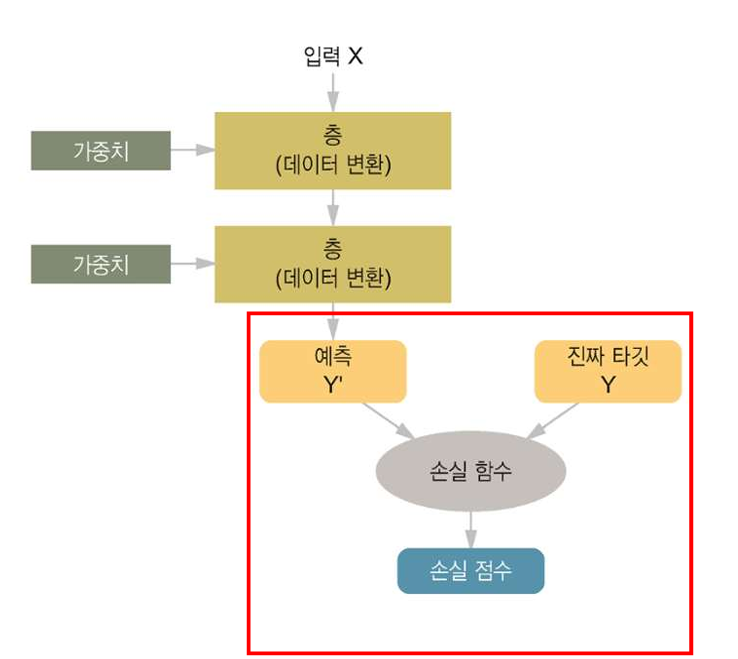

In [117]:
# 하이퍼-파라미터 (숫자를 하드코딩하기보다 하나의 셀 안에 하이퍼 파라미터 설정하고 가져다 쓰는 게 깔끔!)
EPOCHS = 100
BATCH_SIZE = 256
PATIENCE = 20

In [118]:
from keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# ModelCheckpoint함수를 적용해서 val_loss를 기준으로 가장 좋은 성능의 모델을 mnist_best파일명으로 저장
# MC_CB = ModelCheckpoint(filepath='mnist_best.keras', monitor='val_loss', save_best_only=True)
MC_CB = ModelCheckpoint(filepath='mnist_best.keras', monitor='val_accuracy', save_best_only=True)

# ReduceLROnPlateu함수를 적용해서 val_loss를 기준으로 patience=10으로 설정하고 factor=0.5로 설정
# LearningRate (보폭) 조절 파라미터. EarlyStopping이 먼저야. 그거때문에 지금 안 돌 수도있업.
RLROP_CB = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=0.00001)

# EarlyStopping Callback 함수를 적용해서 patience = 10, monitor = 'val_loss'로 설정
# ES_CB = EarlyStopping(monitor='val_loss', patience=PATIENCE)
ES_CB = EarlyStopping(monitor='val_accuracy', patience=PATIENCE)


### 6. 모델 학습(fit)

In [119]:
# valid 추가, callbacks 추가 (callback 함수 여러개 쓰는 경우가 있어서 list 형태로 줘야 함)
history = model.fit(train_images, train_labels, validation_data=(valid_images, valid_labels), epochs=EPOCHS, batch_size=BATCH_SIZE, callbacks=[ES_CB, MC_CB, RLROP_CB])
# epochs=20으로 돌리고 epochs=50으로 바꿔서 다시 돌리면 처음부터 학습하지않아. 이어서 해.
# 우리가 필요한 것은 처음부터의 값. 그래야 그래프를 볼 수 있어. 그러면 신경망 모델링부터, 컴파일 실행하고 다시 실행해야 해
# 에폭을 처음부터 늘려서 오버피팅 확인하고 줄이는 것도 방법!
# 중간에 멈추면 과정 저장 안됨! 끝까지 다 에폭 끝나야 결과 확인 가능!

Epoch 1/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - accuracy: 0.8184 - loss: 0.6086 - val_accuracy: 0.9576 - val_loss: 0.1419 - learning_rate: 0.0010
Epoch 2/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.9637 - loss: 0.1225 - val_accuracy: 0.9672 - val_loss: 0.1049 - learning_rate: 0.0010
Epoch 3/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 7s 29ms/step - accuracy: 0.9761 - loss: 0.0735 - val_accuracy: 0.9731 - val_loss: 0.0854 - learning_rate: 0.0010
Epoch 4/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 0.9862 - loss: 0.0455 - val_accuracy: 0.9782 - val_loss: 0.0743 - learning_rate: 0.0010
Epoch 5/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.9906 - loss: 0.0320 - val_accuracy: 0.9777 - val_loss: 0.0780 - learning_rate: 0.0010
Epoch 6/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - accuracy: 0.9934 - loss: 0.0230 - val_accuracy: 0.9761 - val_loss: 0.0814 - learning_rate: 0.0010
Epoch 7/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.9943 - l

In [114]:
history.history

{'accuracy': [0.9095625281333923,
  0.9677083492279053,
  0.9793958067893982,
  0.9851250052452087,
  0.9896458387374878,
  0.991937518119812,
  0.9937291741371155,
  0.9948124885559082,
  0.9950000047683716,
  0.9961249828338623,
  0.996916651725769,
  0.996708333492279,
  0.9971250295639038,
  0.9957708120346069,
  0.9964583516120911,
  0.9980000257492065,
  0.9984791874885559,
  0.9979375004768372,
  0.9957083463668823,
  0.9974791407585144,
  0.9988750219345093,
  0.9980000257492065,
  0.9968541860580444,
  0.9990208148956299,
  0.9991666674613953,
  0.9990000128746033,
  0.9977499842643738,
  0.997041642665863,
  0.9975833296775818,
  0.9988750219345093,
  0.9993541836738586,
  0.9984791874885559,
  0.9975000023841858,
  0.9976666569709778,
  0.9984791874885559,
  0.9981250166893005,
  0.9989166855812073,
  0.9992499947547913,
  0.9991458058357239,
  0.9990416765213013,
  0.9976041913032532,
  0.9989791512489319,
  0.9995833039283752,
  0.999708354473114,
  0.9989791512489319,
  0

In [121]:
max_val_accuracy = max(history.history['val_accuracy'])
max_val_loss = max(history.history['val_loss'])

print(f"Maximum Validation Accuracy: {max_val_accuracy}")
print(f"Maximum Validation Loss: {max_val_loss}")

Maximum Validation Accuracy: 0.9860833287239075
Maximum Validation Loss: 0.14191694557666779


### 7. Loss, Accuracy 그래프로 확인

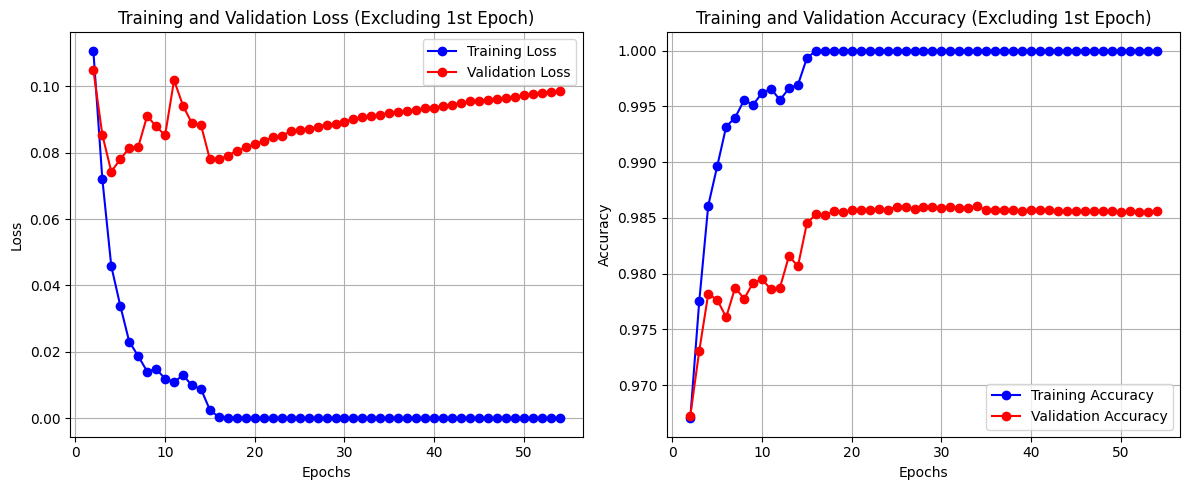

In [122]:
#  loss, accuracy, val_accuracy, val_loss에 대한 모델 그래프를 생성

import matplotlib.pyplot as plt

# Accuracy와 Loss 그래프를 그립니다.
history_dict = history.history
loss = history_dict['loss']
val_loss = history_dict['val_loss']
accuracy = history_dict['accuracy']
val_accuracy = history_dict['val_accuracy']

epochs = range(1, len(loss) + 1)

plt.figure(figsize=(12, 5))

# Loss 그래프 (맨 처음 값 제외)
plt.subplot(1, 2, 1) # 1행 2열 중 첫 번째
plt.plot(epochs[1:], loss[1:], 'bo-', label='Training Loss') # 첫 번째 값 제외
plt.plot(epochs[1:], val_loss[1:], 'ro-', label='Validation Loss') # 첫 번째 값 제외
plt.title('Training and Validation Loss (Excluding 1st Epoch)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Accuracy 그래프 (맨 처음 값 제외)
plt.subplot(1, 2, 2) # 1행 2열 중 두 번째
plt.plot(epochs[1:], accuracy[1:], 'bo-', label='Training Accuracy') # 첫 번째 값 제외
plt.plot(epochs[1:], val_accuracy[1:], 'ro-', label='Validation Accuracy') # 첫 번째 값 제외
plt.title('Training and Validation Accuracy (Excluding 1st Epoch)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### 8. 모델 평가(evaluate)

In [125]:
from keras.models import load_model

# mnist_best.keras 파일으로 로딩해서 모델 평가를 진행
best_model = load_model('mnist_best.keras')

test_loss_best, test_acc_best = best_model.evaluate(test_images, test_labels)
print(f'Best Model Test Loss: {test_loss_best:.4f}')
print(f'Best Model Test Accuracy: {test_acc_best:.4f}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9807 - loss: 0.1038
Best Model Test Loss: 0.0839
Best Model Test Accuracy: 0.9834


In [124]:
test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=2)
print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_acc}")


313/313 - 1s - 3ms/step - accuracy: 0.9835 - loss: 0.0901
Test Loss: 0.0900547057390213
Test Accuracy: 0.9835000038146973
